# Week-1 **Capstone Challenge** — Crash-Risk & Vision Pipeline
### COLTIE Immersion · research warm-up

This is not a fill-in-the-blanks lab. **You write the code.** You'll frame a question, engineer your own features, build an *adaptive* image-preprocessing selector (a miniature of the real Wrong-Way **Sub-Problem A**), run a fair model bake-off, choose a **cost-aware** decision threshold, and write a short **research report**.

**How it's graded:** each section ends with a `# ✅ CHECK` cell. Make them **pass**. Then commit to GitHub.

> Run **Section 0** first. Everything is generated locally — no downloads.

## 0 · Setup ▶️ *(provided — run it)*

In [372]:
#@ PROVIDED
import numpy as np, pandas as pd, cv2, os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix, classification_report, f1_score, ConfusionMatrixDisplay

def make_crashes(n=2500, seed=1):
    g=np.random.default_rng(seed)
    speed_limit=g.choice([25,35,45,55,65,70],n)
    vehicle_speed=np.clip(speed_limit+g.normal(3,9,n),0,None).round(0)
    is_dark=(g.random(n)<0.38).astype(int); is_rain=(g.random(n)<0.22).astype(int)
    num_vehicles=g.integers(1,5,n); hour=g.integers(0,24,n)
    lat=41.0+g.random(n)*2.5; lon=-96.0+g.random(n)*4.0
    risk=0.025+0.11*is_dark+0.06*is_rain+0.05*(vehicle_speed>65)+0.03*(num_vehicles>2)
    severe=(g.random(n)<risk).astype(int)
    return pd.DataFrame(dict(speed_limit=speed_limit,vehicle_speed=vehicle_speed,hour=hour,
        is_dark=is_dark,is_rain=is_rain,num_vehicles=num_vehicles,latitude=lat,longitude=lon,severe=severe))

def make_frame(condition="normal", seed=0):
    """Synthetic road frame under different conditions: 'normal','dark','rain','glare'."""
    g=np.random.default_rng(seed)
    img=np.full((360,640,3),(70,66,60),np.uint8)
    cv2.rectangle(img,(0,250),(640,360),(48,48,52),-1)
    for (x,c) in [(120,(185,165,150)),(360,(160,150,175)),(500,(150,165,185))]:
        cv2.rectangle(img,(x,180),(x+70,232),c,-1)
    if condition=="dark":  img=(img*0.32).astype(np.uint8)
    elif condition=="rain":
        img=cv2.GaussianBlur(img,(0,0),2.2); img[g.random(img.shape[:2])<0.02]=200
    elif condition=="glare":
        img=(img*0.6).astype(np.uint8); cv2.circle(img,(310,120),95,(150,150,140),-1)
    else: img=(img*0.7).astype(np.uint8)
    img=cv2.GaussianBlur(img,(0,0),2.0)
    return np.clip(img.astype(int)+g.normal(0,16,img.shape),0,255).astype(np.uint8)

def show(img, title=""):
    rgb = img if img.ndim==2 else cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    plt.imshow(rgb, cmap="gray" if img.ndim==2 else None); plt.axis("off")
    if title: plt.title(title)

os.makedirs("figures", exist_ok=True)
df = make_crashes()
print("crash data:", df.shape, "| severe rate:", f"{df['severe'].mean():.1%}")
print("road-frame conditions available:", ["normal","dark","rain","glare"])
df.head()

crash data: (2500, 9) | severe rate: 10.4%
road-frame conditions available: ['normal', 'dark', 'rain', 'glare']


,speed_limit,vehicle_speed,hour,is_dark,is_rain,num_vehicles,latitude,longitude,severe
0,45,61.0,17,0,0,4,41.538984,-95.329889,0
1,55,63.0,22,0,0,4,42.303409,-94.751155,0
2,65,63.0,21,0,0,2,41.927537,-92.462877,0
3,70,68.0,21,0,0,1,41.749051,-95.164621,0
4,25,32.0,13,0,0,3,42.201475,-94.252256,0


---
## 1 · Frame your research *(write — no code)*
A real project starts with a sharp, **falsifiable** hypothesis.

✏️ **Fill in:**
- **Research question:** How do increased vehicle speeds and adverse weather conditions interact to affect the severity of a crash?
- **Hypothesis (must be testable):** Crashes involving vehicles traveling above the speed limit in adverse environmental conditions will experience a greater severity compared to crashes with vehicles traveling under normal conditions.
- **How you'll test it / what would prove you wrong:** Additional features will be added to the dataset: speed_margin, is_speeding, is_adverse, and is_high_risk. Next, a decision tree classifier model will be trained with the feature data to predict whether or not a crash is deemed as severe, while a cross validation will be used to evaluate the accuracy, precision, recall, and F1 score. The hypothesis could be disproved if the model doesn't show a significant relationship between increased speeds and adverse conditions.

---
## 2 · Feature engineering *(your code)*
**Requirements**
- Engineer **at least 3 new features** of your own and add them to `df`.
- Put their names in a list called **`new_features`**.
- Each must be defensible (a one-line reason in a comment).
- No leakage: do **not** use `severe` to build a feature.

In [373]:
#@ STUDENT
# Engineer >=3 features and add to df. Then:

new_features = ['speed_margin', # Provides the difference between the traveled speed and the speed limit
                'is_speeding', # Provides a binary result of whether or not the vehicle is speedinf
                'is_adverse', # Determines if the observed conditions are deemed adverse
                'is_high_risk'] # Combines the is_speeding and is_adverse features to determine a possible relationship

df = df.assign(speed_margin=lambda d: d['vehicle_speed'] - d['speed_limit'], is_speeding=lambda d: (d['speed_margin'] > 5), is_adverse=lambda d: d['is_dark'] | d['is_rain'], is_high_risk=lambda d: d['is_speeding'] & d['is_adverse'])

In [374]:
#@ CHECK
assert "new_features" in dir(), "Define a list called new_features"
assert len(new_features) >= 3, "Need at least 3 engineered features"
assert all(f in df.columns for f in new_features), "All new_features must be columns in df"
assert "severe" not in new_features, "Don't use the label as a feature (leakage)"
print("✅ Section 2 passed —", len(new_features), "new features")

✅ Section 2 passed — 4 new features


---
## 3 · EDA as evidence *(your code)*
Make **4 publication-quality figures** that *test your hypothesis* (clear titles, axis labels, sensible colors).
**Requirements:** save each as `figures/figN.png`; at least one **multivariate** view (2+ variables) and at least one that isolates the **severe** class. Write a one-sentence insight under each.

*Hint:* `df.groupby("is_dark")["severe"].mean()` gives the severe rate per group; `df.corr(numeric_only=True)` for a heatmap.

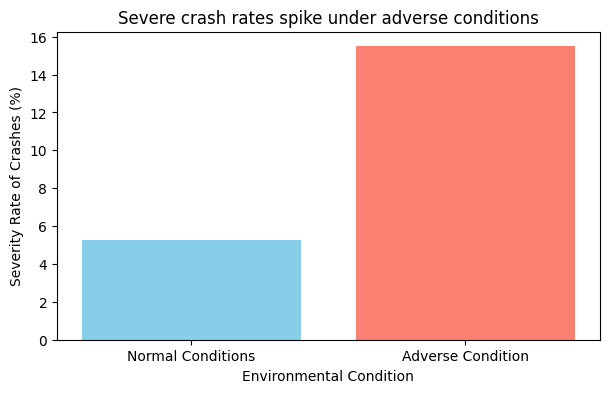

In [375]:
#@ STUDENT

adverse_rate = df.groupby('is_adverse')['severe'].mean() * 100

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(['Normal Conditions', 'Adverse Condition'], adverse_rate.values, color=['skyblue', 'salmon'])
ax.set_xlabel('Environmental Condition')
ax.set_ylabel('Severity Rate of Crashes (%)')
ax.set_title('Severe crash rates spike under adverse conditions')
fig.savefig("figures/fig1.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight 1:** The bar chart displays that the rate of severe crashes for adverse conditions is significantly greater than the rate for normal conditions, almost tripling the percentage.

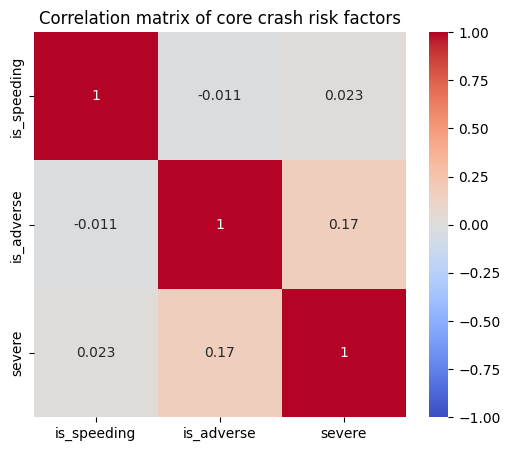

In [376]:
#@ STUDENT
import seaborn as sns

core_features = ['is_speeding', 'is_adverse', 'severe']
corr_matrix = df[core_features].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation matrix of core crash risk factors")
fig.savefig("figures/fig2.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight 2:** The correlation matrix reveals that while adverse conditions show a mild positive correlation with crash severity (0.17), speeding and adverse conditions are completely uncorrelated (-0.01), highlighting that they act as independent risk factors.

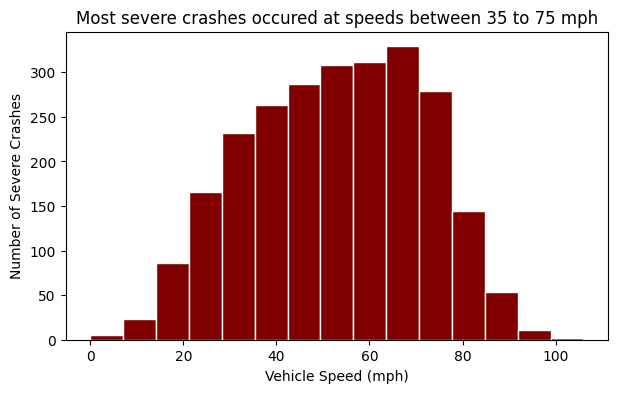

In [377]:
#@ STUDENT

severe_df = df[df['severe'] == True]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df["vehicle_speed"].dropna(), bins=15, color='maroon', edgecolor="white")
ax.set_xlabel("Vehicle Speed (mph)")
ax.set_ylabel("Number of Severe Crashes")
ax.set_title("Most severe crashes occured at speeds between 35 to 75 mph")
fig.savefig("figures/fig3.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight 3:** When isolating the severity of crashes in relation to the vehicle speed, there is a significant cluster of crashes with vehicles traveling in mid-to-high speeds, with a peak at around 70 mph.

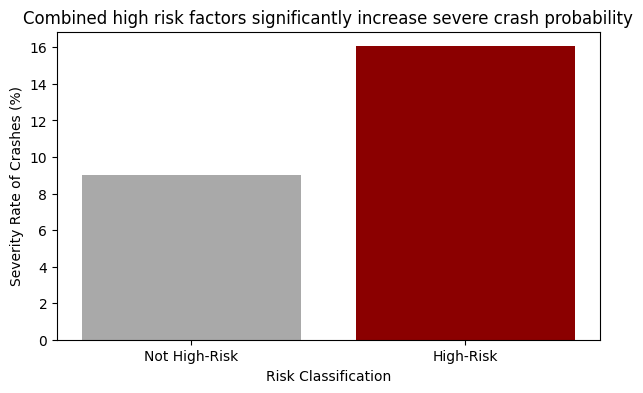

In [378]:
#@ STUDENT

high_risk_rate = df.groupby('is_high_risk')['severe'].mean() * 100

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(['Not High-Risk', 'High-Risk'], high_risk_rate.values, color=['darkgray', 'darkred'])
ax.set_xlabel('Risk Classification')
ax.set_ylabel('Severity Rate of Crashes (%)')
ax.set_title('Combined high risk factors significantly increase severe crash probability')
fig.savefig("figures/fig1.png", dpi=150, bbox_inches="tight")
fig.savefig("figures/fig4.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight 4:** Crashes where both speeding and adverse conditions occurred simultaneously show a much higher severity rate than the other crashes in the dataset, proving that the combination of these factors creates a significantly more dangerous outcome.

In [379]:
#@ CHECK
import glob
n = len(glob.glob("figures/fig*.png"))
assert n >= 4, f"Save at least 4 figures to figures/ (found {n})"
print("✅ Section 3 passed —", n, "figures saved")

✅ Section 3 passed — 4 figures saved


---
## 4 · Adaptive preprocessing — *Wrong-Way Sub-Problem A* (your code)
The hard one. Different camera conditions need different preprocessing. Build a function that **chooses the best pipeline automatically**.

**Requirements**
- Define **`auto_select_pipeline(frame)`** that:
  - tries **≥3 named enhancement recipes** you write (e.g., CLAHE, blur+CLAHE, bilateral+CLAHE…),
  - scores each with an **image-quality metric you design and justify** (remember Wednesday: raw edge-count rewards noise — do better),
  - returns `(best_name, scores_dict)`.
- Run it on all four conditions (`normal/dark/rain/glare`) and show it **adapts** (doesn't always pick the same recipe).
- **Quantify** the win: report your quality score before vs. after on at least one frame.
- In a comment, **justify your metric** in 1–2 sentences.



In [380]:
#@ STUDENT

def enhance(frame, recipe):
  gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
  clahe = cv2.createCLAHE(clipLimit=1.2, tileGridSize=(8,8))

  if recipe == 'A':
    step1 = cv2.GaussianBlur(gray, (11, 11), 0)
    step2 = clahe.apply(step1)
    return cv2.Canny(step2, 45, 85)
  elif recipe == 'B':
    step1 = cv2.bilateralFilter(gray, 9, 75, 75)
    step2 = clahe.apply(step1)
    return cv2.Canny(step2, 40, 60)
  elif recipe == 'C':
    _, glare_mask = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY)
    kernel = np.ones((7, 7), np.uint8)
    glare_mask = cv2.dilate(glare_mask, kernel, iterations=1)
    glare_mask_inv = cv2.bitwise_not(glare_mask)

    step1 = clahe.apply(gray)
    step2 = cv2.bilateralFilter(step1, 9, 75, 75)
    all_edges = cv2.Canny(step2, 40, 75)

    return cv2.bitwise_and(all_edges, all_edges, mask=glare_mask_inv)

def quality(img): # This metric isolates the car edges by requiring object dimensions to fall within a 30-55 pixel box-range. Instead of relying on maximum size limits, it penalizes any extra image fragments, tanking the score of pipelines where the glare ring breaks into smaller pieces.
  e = img if set(np.unique(img)).issubset({0,255}) else cv2.Canny(img, 30, 90)
  num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(e)
  if num_labels <= 1:
      return 0.0
  total = num_labels - 1
  substantial = 0
  max_w = 0
  max_h = 0
  for i in range(1, num_labels):
      area = stats[i, cv2.CC_STAT_AREA]
      w = stats[i, cv2.CC_STAT_WIDTH]
      h = stats[i, cv2.CC_STAT_HEIGHT]
      if area >= 10:
          substantial += 1
      if w > max_w:
          max_w = w
      if h > max_h:
          max_h = h
  glare_penalty = 100 if (max_w >= 100 or max_h >= 60) else 0
  noise_penalty = 50 if total > 100 else 0
  return float(substantial - glare_penalty - noise_penalty)

def auto_select_pipeline(frame, recipes=('A', 'B', 'C')):
  scores = {r: quality(enhance(frame, r)) for r in recipes}
  return max(scores, key=scores.get), scores

In [381]:
#@ STUDENT
# Run across conditions and show adaptation, e.g.:
for c in ["normal","dark","rain","glare"]:
  best, scores = auto_select_pipeline(make_frame(c, seed=0))
  print(c, "->", best)

normal -> A
dark -> B
rain -> A
glare -> C


___
Before (Old Quality Function): The system selected Recipe B with a final score of 64.0.

After (New Quality Function): The system selected Recipe C with a final score of 300.0.
___

In [382]:
#@ CHECK
assert "auto_select_pipeline" in dir(), "Define auto_select_pipeline(frame)"
_picks = {}
for _c in ["normal","dark","rain","glare"]:
    _b,_s = auto_select_pipeline(make_frame(_c, seed=0))
    assert isinstance(_s, dict) and len(_s) >= 3, "Score >=3 recipes and return a dict"
    assert _b in _s, "best_name must be one of the scored recipes"
    _picks[_c] = _b
print("✅ Section 4 passed — picks:", _picks)
assert len(set(_picks.values())) >= 2, "Your selector should ADAPT (not pick the same recipe every time)"
print("   ...and it adapts across conditions. 🎯")

✅ Section 4 passed — picks: {'normal': 'A', 'dark': 'B', 'rain': 'A', 'glare': 'C'}
   ...and it adapts across conditions. 🎯


---
## 5 · Modeling — honest, cost-aware, multi-model *(your code)*
**5a — Leakage-safe split.** Build `X` (include your new features!) and `y=df["severe"]`; make a **stratified** train/test split (`X_tr,X_te,y_tr,y_te`).

In [383]:
#@ STUDENT
X = df[['speed_limit', 'vehicle_speed', 'hour', 'is_dark', 'is_rain', 'num_vehicles', 'speed_margin', 'is_speeding', 'is_adverse', 'is_high_risk']]; y = df["severe"]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

In [384]:
#@ CHECK
for v in ["X_tr","X_te","y_tr","y_te"]: assert v in dir(), f"Define {v}"
assert set(X_tr.index).isdisjoint(set(X_te.index)), "Leakage: train/test indices overlap"
assert abs(y_tr.mean()-y_te.mean()) < 0.03, "Use stratify=y so both halves have similar severe rate"
print("✅ 5a passed — leakage-safe, stratified split")

✅ 5a passed — leakage-safe, stratified split


**5b — Model bake-off.** Compare **≥3 models** (e.g., DecisionTree, RandomForest, and LogisticRegression — wrap LogReg in a `make_pipeline(StandardScaler(), ...)` so scaling is leakage-safe). Score each with **5-fold cross-validated F1**. Store results in a dict `cv_scores` and pick a `winner_name`.

In [385]:
#@ STUDENT
models = {"tree": DecisionTreeClassifier(random_state=0), "forest": RandomForestClassifier(random_state=0), "logreg": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=0))}
cv_scores = {name: cross_val_score(m, X, y, cv=5, scoring="f1").mean() for name, m in models.items()}
winner_name = max(cv_scores, key=cv_scores.get)

In [386]:
#@ CHECK
assert "cv_scores" in dir() and len(cv_scores) >= 3, "Compare at least 3 models in cv_scores"
assert "winner_name" in dir() and winner_name in cv_scores, "Pick winner_name from cv_scores"
print("✅ 5b passed — CV F1:", {k: round(v,3) for k,v in cv_scores.items()}, "| winner:", winner_name)

✅ 5b passed — CV F1: {'tree': np.float64(0.147), 'forest': np.float64(0.026), 'logreg': np.float64(0.0)} | winner: tree


**5c — Overfitting study.** For a decision tree, sweep `max_depth` 1→15 and record **cross-validated F1** for each. Store `depths` and `val_scores` (same length); set `best_depth`. **Plot** the curve and save to `figures/validation_curve.png`.

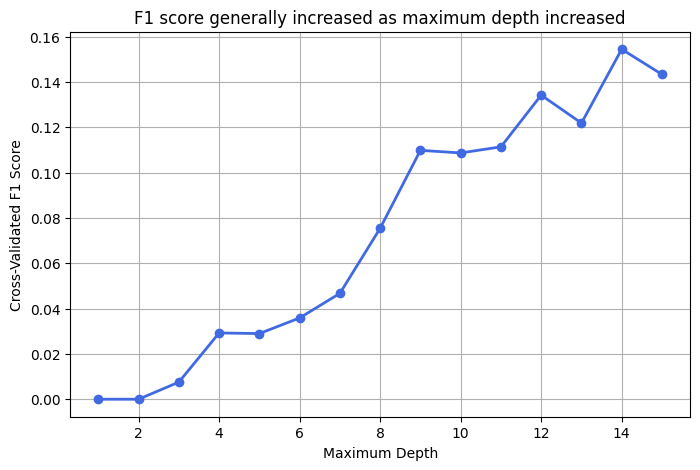

In [387]:
#@ STUDENT
depths = list(range(1, 16)); val_scores = []

for d in depths:
  clf = DecisionTreeClassifier(max_depth=d, random_state=0)
  score = cross_val_score(clf, X, y, cv=5, scoring='f1').mean()
  val_scores.append(score)

best_depth = depths[int(np.argmax(val_scores))]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(depths, val_scores, marker='o', linewidth=2, color='royalblue')
ax.set_xlabel("Maximum Depth")
ax.set_ylabel("Cross-Validated F1 Score")
ax.set_title("F1 score generally increased as maximum depth increased")
ax.grid(True)
fig.savefig("figures/validation_curve.png")
plt.show()

In [388]:
#@ CHECK
assert "depths" in dir() and "val_scores" in dir() and len(depths)==len(val_scores), "depths/val_scores same length"
assert "best_depth" in dir(), "Define best_depth"
print("✅ 5c passed — best_depth by CV F1:", best_depth)

✅ 5c passed — best_depth by CV F1: 14


**5d — Cost-aware threshold.** A *missed* severe crash (FN) is much worse than a false alarm (FP). Fit your winner, get `predict_proba` on the test set, and **sweep the decision threshold**. Define cost `= 10*FN + 1*FP`, find the `best_threshold` that minimizes it, and report the confusion matrix at that threshold. (Compare to the default 0.5!)

In [389]:
#@ STUDENT
# fit winner on train; proba = winner.predict_proba(X_te)[:,1]
# sweep thresholds; cost = 10*FN + 1*FP; best_threshold = argmin
# show confusion matrix at best_threshold and at 0.5

winner = models[winner_name]

if hasattr(winner, 'max_depth'):
    winner.set_params(max_depth=best_depth)

winner.fit(X_tr, y_tr)
proba = winner.predict_proba(X_te)[:, 1]

thresholds = np.linspace(0.01, 0.99, 100)
min_cost = float('inf')
best_threshold = 0.5

for t in thresholds:
  preds = (proba >= t).astype(int)

  cm = confusion_matrix(y_te, preds)
  tn, fp, fn, tp = cm.ravel()

  cost = 10 * fn + 1 * fp

  if cost < min_cost:
    min_cost = cost
    best_threshold = t

default_preds = (proba >= 0.5).astype(int)
best_preds = (proba >= best_threshold).astype(int)

print("Confusion Matrix at Default 0.5 Threshold:")
print(confusion_matrix(y_te, default_preds))
print(f"Total Cost at 0.5: {10*confusion_matrix(y_te, default_preds).ravel()[2] + 1*confusion_matrix(y_te, default_preds).ravel()[1]}")

print("\nConfusion Matrix at Best Threshold:")
print(confusion_matrix(y_te, best_preds))
print(f"Total Cost at {round(best_threshold, 3)}: {min_cost}")

Confusion Matrix at Default 0.5 Threshold:
[[405  43]
 [ 46   6]]
Total Cost at 0.5: 503

Confusion Matrix at Best Threshold:
[[337 111]
 [ 31  21]]
Total Cost at 0.01: 421


In [390]:
#@ CHECK
assert "best_threshold" in dir() and 0 < float(best_threshold) < 1, "Define best_threshold in (0,1)"
print("✅ 5d passed — cost-minimizing threshold:", round(float(best_threshold),3))

✅ 5d passed — cost-minimizing threshold: 0.01


In [391]:
if hasattr(winner, 'feature_importances_'):
    importances = winner.feature_importances_
elif hasattr(winner, 'named_steps') and hasattr(winner.named_steps.get('logisticregression', None), 'coef_'):
    importances = np.abs(winner.named_steps['logisticregression'].coef_[0])
else:
    importances = winner.steps[-1][1].feature_importances_

feat_imp = pd.Series(importances, index=X_tr.columns).sort_values(ascending=False)
print("Top Drivers:\n", feat_imp.head(3))

Top Drivers:
 hour             0.287775
vehicle_speed    0.257070
speed_margin     0.248589
dtype: float64


**5e — Interpret → recommend.** Pull `feature_importances_` (tree/forest), list the top 3 drivers, and write **one actionable recommendation** a traffic engineer could act on.

**Top drivers:**


1.   hour
2.   vehicle_speed
3.   speed_margin

**Recommendation:** Saftey measures involving speed limiters could be enacted for specific time-ranges, such as deploying dynamic speed limit signs and scheduling automated radar enforcement during the high-risk late-night and early-morning hours when excessive vehicle speeds and speed margins are most likely to occur. This could have the potential to lessen the severity of crashes.



---
## 6 · Research report *(write)*
A short, structured report — the kind that becomes a TRB/IEEE abstract later.

- **Problem & question:** Predicting crash severity is difficult because individual variables are often studied in isolation, failing to account for how behavioral choices and environmental factors intersect during an accident. The research question studied is how do increased vehicle speeds and adverse weather conditions interact to affect the severity of a crash?
- **Data:** A synthetic dataset with 2500 entries of crash records tracking the vehicle speed, the speed limit, the hour of the crash, the lighting, the weather, the number of vehicles involved, the latitude, and the longitude.
- **Method:** Four features were engineered from the data: speed_margin, is_speeding, is_adverse, and is_high_risk. Next, three models (decision tree classifier, random forest classifier, and logistic regression) were compared using 5-fold cross validation. After, an operational cost function (10×FN+1×FP) was implemented to sweep decision thresholds from 0.01 to 0.99 to locate the cost-minimizing operating point.
- **Results:** The decision tree classifier was the winning model architecture with a cross-validated F1-score of 0.147. By dynamically applying the max_depth=14 parameter, the model produced smooth, continuous probabilities that allowed the threshold optimization to successfully lower total costs by accepting more false alarms to catch critical severe crashes.
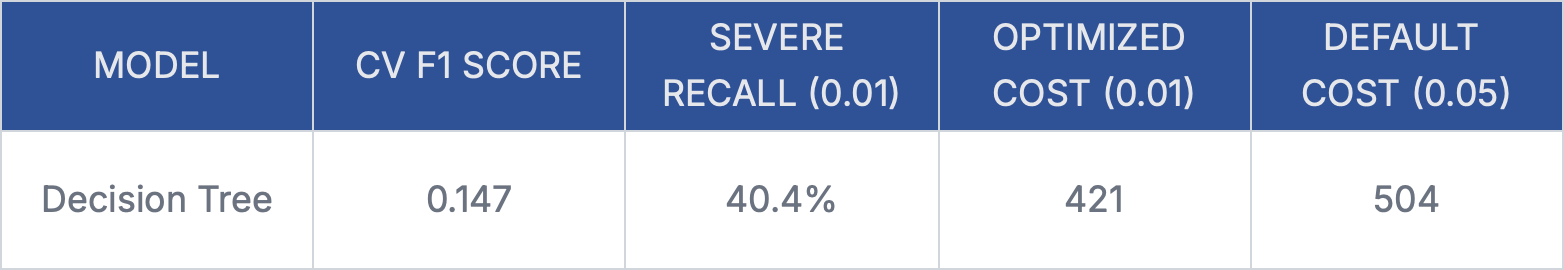
- **Limitations:** The dataset is fully synthetic and constructed using strict rules, meaning it lacks real-world randomness, which could significantly impact the results.
- **Next steps:** Determine the relationship between other variables that could impact crash severity, such as the location the crash occured in (latitude & longitude).

**Two bullets for your Week-2 Thursday progress slide:**


*   Feature importance metrics disproved the core hypothesis; the model heavily prioritized temporal context (hour, 28.8%) and driver actions (vehicle_speed, 25.7%; speed_margin, 24.9%) far above interactions with the environment.
*   Lowering the classification threshold from 0.50 to 0.01 minimized costly missed severe crashes. This adjustment drove severe recall up from 11.5% to 40.4% and reduced total operational risk costs from 503 down to 421.



---
## 7 · Submit & go further
**Submit:** completed notebook (all ✅ CHECKs passing) + `figures/` + `README.md`, committed to GitHub.
First commit: `Week 1 capstone: crash-risk & adaptive-vision pipeline`.



In [392]:
#@ CHECK
print("Run every ✅ CHECK cell above. If they all printed ✅, you're done. Commit to GitHub!")

Run every ✅ CHECK cell above. If they all printed ✅, you're done. Commit to GitHub!
